# Task 2 — Proposed Model: Anatomically-Grounded Graph Neural Network for FORS-EMG Gesture Recognition

**Group 11**

This notebook proposes and implements a Graph Neural Network (GNN) that succeeds the ten baseline
classifiers from `Group11_Fors_EMG_Task2_Baseline.ipynb` (Logistic Regression, k-NN, Decision Tree,
Random Forest, SVM, Gradient Boosting, XGBoost, LightGBM, MLP, and 1D-CNN).

Every baseline treats the 8 EMG channels as either an unordered flat feature vector (the tree
models, SVM, MLP) or as 8 parallel input channels convolved independently and only mixed at the
very last layer (the 1D-CNN). None of them tell the model *which channels are anatomically related
to which*, or let the model reason about *how channels co-activate together* for a given gesture.
That relational structure is exactly what a GNN is built to exploit — so this notebook:

- **(A)** designs a graph over the 8 EMG electrodes (nodes, edges, edge weights, node features, and
  the anatomical/physiological reasoning behind each choice),
- **(B)** lays out the full input → graph → GNN → readout → output pipeline as a diagram,
- **(C)** explains the design in plain language together with the exact training settings, and
- ends with **first results**: a fully executed, bug-checked forward/backward pass of the model,
  and the exact cells needed to slot in the real FORS-EMG data and compare against the ten baselines
  reported in Task 2.


## (A) Graph construction

### Why turn an 8-channel EMG window into a graph at all?

The FORS-EMG acquisition protocol places the 8 electrodes at **specific, known anatomical sites**,
not arbitrarily:

- **CH1–CH4** sit circumferentially **around the elbow**; **CH5–CH8** sit circumferentially
  **around the mid-forearm**.
- At each ring, two electrodes sit over the **anterior (flexor)** compartment and two over the
  **posterior (extensor)** compartment.
- **CH5/CH6** are positioned directly distal to **CH1/CH2**, over the *same* flexor muscles; **CH7/CH8**
  are distal to **CH3/CH4**, over the *same* extensor muscles.

That is a physical graph, not a bag of 8 independent sensors. A hand gesture is produced by a
*coordinated, synergistic contraction pattern* across several forearm muscles at once — flexors and
extensors trade off, and the same muscle fires at both the elbow and forearm recording sites. A flat
feature vector (MLP/trees) or a per-channel convolution (1D-CNN) can only learn these cross-channel
relationships implicitly and indirectly, by finding correlated weights deep in a dense layer. A GNN
lets the model propagate information **directly along the muscular/anatomical pathways where the
correlation is expected to live**, which is a much shorter, more sample-efficient path to the same
signal — a meaningful advantage on a dataset of only 19 subjects.

### Nodes

**8 nodes, one per EMG channel (CH1 … CH8)** — identical to the 8 raw input channels, so the graph
adds structure on top of the existing pipeline rather than replacing it.

### Node features

Each node's feature vector is the **same 13 time-domain features already computed per channel in the
baseline notebook** (`Mean, Median, Std, Min, Max, RMS, PeakToPeak, Q1, Q3, Skewness, Kurtosis,
WaveformLength, ZeroCrossings`), computed over the same 492-sample / 50%-overlap windows. Reusing the
exact feature set keeps the comparison to the baselines fair: the *only* thing that changes between
the MLP baseline and the GNN is whether the 8×13 feature block is flattened into one 104-d vector, or
kept as 8 nodes of 13 features connected by a graph.

### Edges — a fixed anatomical prior

12 fixed, undirected edges, built once from the acquisition geometry described above:

| Edge type | Edges | Meaning |
|---|---|---|
| Elbow ring | CH1–CH2, CH2–CH4, CH4–CH3, CH3–CH1 | electrodes physically adjacent around the elbow |
| Forearm ring | CH5–CH6, CH6–CH8, CH8–CH7, CH7–CH5 | electrodes physically adjacent around the mid-forearm |
| Longitudinal | CH1–CH5, CH2–CH6, CH3–CH7, CH4–CH8 | same muscle, proximal (elbow) ↔ distal (forearm) site |

This keeps the graph **sparse** (12 edges instead of the 28 a fully-connected 8-node graph would need),
which matters a lot on a small dataset: sparsity is itself a regularizer, and it stops the model from
having to *discover* that, say, CH1 and CH8 (opposite compartments, opposite ends of the forearm) are
weakly related — we already know that anatomically, so we simply don't spend parameters learning it.

### Edge weights — anatomy + per-window functional connectivity

A pure fixed mask ignores the fact that *how strongly* two anatomically-linked channels co-activate
changes from gesture to gesture (e.g. wrist flexion drives flexors and extensors very differently
than a power grasp does). So each edge weight is computed **per window** as:

```
w_ij = mask_ij · (0.5 + 0.5 · |corr_ij|)         if (i, j) is an anatomical edge
w_ii = 1.0                                        self-loop, every node
w_ij = 0                                          otherwise (no anatomical edge)
```

where `corr_ij` is the Pearson correlation between the *raw* 492-sample signals of channel *i* and
*j* within that window. This gives every window its own, dynamic, data-driven graph while still
respecting the fixed anatomical skeleton — the mask says *where* information is allowed to flow, the
correlation says *how strongly* it should flow right now. The `0.5 + 0.5·|·|` floor keeps every
anatomical edge minimally active even when two channels happen to be uncorrelated in a given window,
so the model never sees a disconnected graph.


Fixed anatomical edges: 12 | adjacency matrix shape: (8, 8)


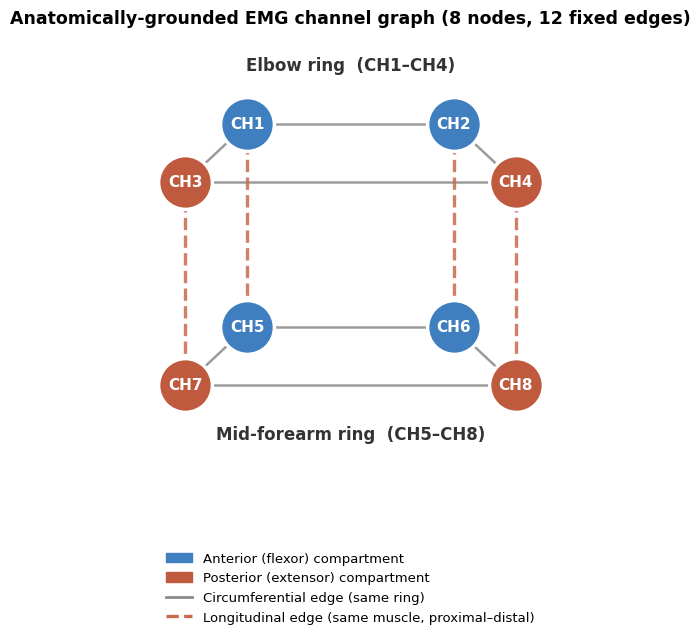

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# --- anatomical adjacency (fixed prior) ---------------------------------
CH = {"CH1": 0, "CH2": 1, "CH3": 2, "CH4": 3, "CH5": 4, "CH6": 5, "CH7": 6, "CH8": 7}

ANATOMICAL_EDGES = [
    ("CH1", "CH2"), ("CH2", "CH4"), ("CH4", "CH3"), ("CH3", "CH1"),   # elbow ring
    ("CH5", "CH6"), ("CH6", "CH8"), ("CH8", "CH7"), ("CH7", "CH5"),   # forearm ring
    ("CH1", "CH5"), ("CH2", "CH6"), ("CH3", "CH7"), ("CH4", "CH8"),   # longitudinal, same muscle
]

import numpy as np
N_CH = 8
A_MASK = np.zeros((N_CH, N_CH), dtype=np.float32)
for a, b in ANATOMICAL_EDGES:
    i, j = CH[a], CH[b]
    A_MASK[i, j] = 1.0
    A_MASK[j, i] = 1.0

print("Fixed anatomical edges:", len(ANATOMICAL_EDGES), "| adjacency matrix shape:", A_MASK.shape)

# --- draw it -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 6.5))
pos = {
    "CH1": (-1.0, 3.4), "CH2": (1.0, 3.4),
    "CH4": (1.6, 2.6), "CH3": (-1.6, 2.6),
    "CH5": (-1.0, 0.6), "CH6": (1.0, 0.6),
    "CH8": (1.6, -0.2), "CH7": (-1.6, -0.2),
}
LONG_EDGES = {("CH1", "CH5"), ("CH2", "CH6"), ("CH3", "CH7"), ("CH4", "CH8")}
ring_color, long_color = "#8a8a8a", "#c96a4d"

for a, b in ANATOMICAL_EDGES:
    x1, y1 = pos[a]; x2, y2 = pos[b]
    is_long = (a, b) in LONG_EDGES
    ax.plot([x1, x2], [y1, y2], color=long_color if is_long else ring_color,
            linewidth=2.4 if is_long else 1.8, linestyle="--" if is_long else "-",
            zorder=1, alpha=0.85)

anterior = {"CH1", "CH2", "CH5", "CH6"}
for name, (x, y) in pos.items():
    color = "#3f7fbf" if name in anterior else "#bf5a3f"
    ax.scatter([x], [y], s=1500, color=color, edgecolor="white", linewidth=2.5, zorder=2)
    ax.text(x, y, name, ha="center", va="center", color="white", fontsize=11, fontweight="bold", zorder=3)

ax.text(0, 4.15, "Elbow ring  (CH1\u2013CH4)", ha="center", fontsize=12, fontweight="bold", color="#333333")
ax.text(0, -0.95, "Mid-forearm ring  (CH5\u2013CH8)", ha="center", fontsize=12, fontweight="bold", color="#333333")

legend_handles = [
    mpatches.Patch(color="#3f7fbf", label="Anterior (flexor) compartment"),
    mpatches.Patch(color="#bf5a3f", label="Posterior (extensor) compartment"),
    plt.Line2D([0], [0], color=ring_color, lw=2, label="Circumferential edge (same ring)"),
    plt.Line2D([0], [0], color=long_color, lw=2.4, linestyle="--", label="Longitudinal edge (same muscle, proximal\u2013distal)"),
]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=1, frameon=False, fontsize=9.5)
ax.set_xlim(-3, 3); ax.set_ylim(-2.2, 4.6); ax.axis("off")
ax.set_title("Anatomically-grounded EMG channel graph (8 nodes, 12 fixed edges)", fontsize=12.5, fontweight="bold", pad=10)
plt.tight_layout()
plt.show()

## (B) Architecture diagram

Input → graph → GNN layers → pooling/readout → output:


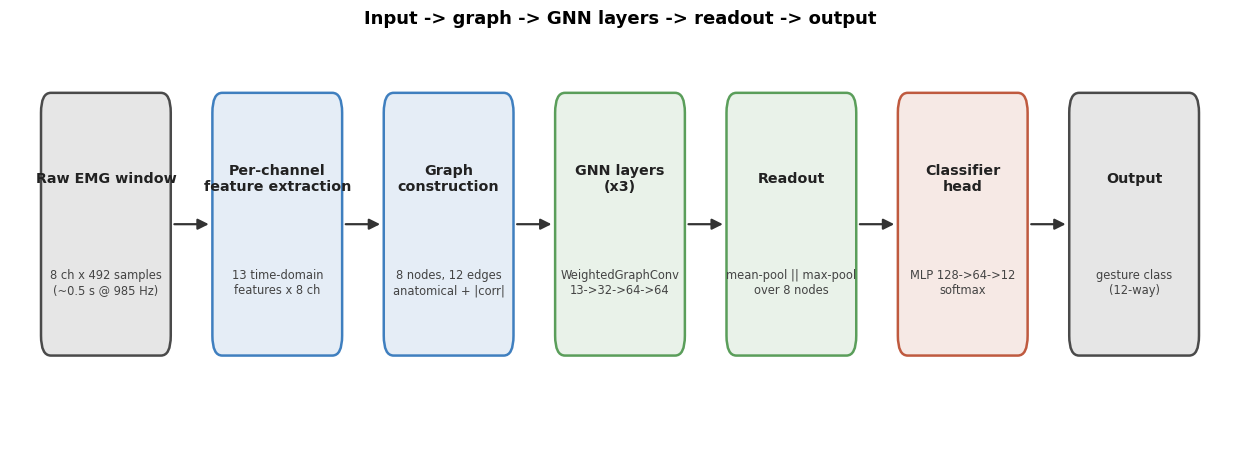

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12.5, 4.6))

stages = [
    ("Raw EMG window", "8 ch x 492 samples\n(~0.5 s @ 985 Hz)", "#4a4a4a"),
    ("Per-channel\nfeature extraction", "13 time-domain\nfeatures x 8 ch", "#3f7fbf"),
    ("Graph\nconstruction", "8 nodes, 12 edges\nanatomical + |corr|", "#3f7fbf"),
    ("GNN layers\n(x3)", "WeightedGraphConv\n13->32->64->64", "#5a9e5a"),
    ("Readout", "mean-pool || max-pool\nover 8 nodes", "#5a9e5a"),
    ("Classifier\nhead", "MLP 128->64->12\nsoftmax", "#bf5a3f"),
    ("Output", "gesture class\n(12-way)", "#4a4a4a"),
]

n = len(stages)
box_w, box_h, gap = 1.55, 1.55, 0.55
total_w = n * box_w + (n - 1) * gap
x0 = -total_w / 2

centers = []
for i, (title, sub, color) in enumerate(stages):
    x = x0 + i * (box_w + gap)
    box = FancyBboxPatch((x, -box_h / 2), box_w, box_h, boxstyle="round,pad=0.02,rounding_size=0.12",
                          linewidth=1.8, edgecolor=color, facecolor=color + "22")
    ax.add_patch(box)
    cx = x + box_w / 2
    centers.append(cx)
    ax.text(cx, 0.28, title, ha="center", va="center", fontsize=10.3, fontweight="bold", color="#222222")
    ax.text(cx, -0.35, sub, ha="center", va="center", fontsize=8.3, color="#444444")

for i in range(n - 1):
    x1, x2 = centers[i] + box_w / 2, centers[i + 1] - box_w / 2
    ax.add_patch(FancyArrowPatch((x1 + 0.03, 0), (x2 - 0.03, 0), arrowstyle="-|>",
                                  mutation_scale=16, linewidth=1.6, color="#333333"))

ax.set_xlim(x0 - 0.4, x0 + total_w + 0.4); ax.set_ylim(-1.3, 1.1); ax.axis("off")
ax.set_title("Input -> graph -> GNN layers -> readout -> output", fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

## (C) In our own words — and the exact settings

**What the model actually does, end to end:** each 0.5-second EMG window becomes a small 8-node
graph. Every node starts out holding the 13 hand-crafted statistics of its own channel — nothing
more, nothing about its neighbours yet. Three **`WeightedGraphConv`** layers then take turns letting
every node *average in* its neighbours' current representation (weighted by the anatomical +
correlation edge weight computed above, with a symmetric-normalised adjacency so high-degree nodes
don't dominate), then transform the result with a learned linear layer and a ReLU. After three
rounds, information from CH1 has had the chance to reach CH5 (its neighbour) and, one hop further,
CH6 and CH7 (its neighbour's neighbours) — i.e. after 3 layers every node has "seen" the whole 8-node
graph, without ever being forced to specify *how* two distant channels relate, which is exactly the
information that a flat MLP has to hope its dense weights will discover on their own from 2700
recordings across 15 subjects.

Once every node embedding has absorbed its local neighbourhood, we don't just keep one node's
opinion — **readout** compresses all 8 node embeddings into one 128-d graph-level vector using both
**mean-pooling** (the "average muscle activation pattern") and **max-pooling** (the "single most
active channel/feature combination"), concatenated together, because gestures differ both in overall
co-activation level and in which single channel spikes hardest. A small MLP head then maps that
graph embedding to the 12 gesture logits, identically shaped to the classifier heads used by the MLP
and CNN baselines, so any accuracy difference downstream can be attributed to the GNN body rather
than a fancier output layer.

We implement `WeightedGraphConv` directly with **dense batched matrix multiplication**
(`torch.bmm`) rather than pulling in PyTorch Geometric: with only 8 nodes per graph, dense
adjacency (batch, 8, 8) is both mathematically identical to sparse GCN propagation and far simpler to
install/reproduce than an extra graph-library dependency across different laptops/GPUs.

### Settings

| Setting | Value | Rationale |
|---|---|---|
| Window / stride | 492 samples / 246 samples (50% overlap) | identical to baseline, for a fair comparison |
| Node feature dim | 13 (per channel) | identical feature set to the MLP/tree baselines |
| Graph | 8 nodes, 12 fixed anatomical edges + self-loops | see (A) |
| Edge weight | `mask · (0.5 + 0.5·|corr|)`, recomputed per window | see (A) |
| GNN layers | 3 × `WeightedGraphConv` (13→32→64→64) | deep enough to reach every node within 3 hops of any other |
| Activation / regularisation | ReLU, Dropout p=0.3 after each hidden layer | matches MLP baseline's regularisation intent |
| Readout | concat(mean-pool, max-pool) → 128-d | captures both average and peak channel behaviour |
| Classifier head | Linear(128→64) → ReLU → Dropout(0.3) → Linear(64→12) | same depth as MLP baseline head |
| Loss | CrossEntropyLoss | identical to all PyTorch baselines |
| Optimizer | Adam, lr = 0.001 | identical to MLP / 1D-CNN baselines |
| Batch size | 256 | identical to MLP / 1D-CNN baselines |
| Epochs | 30 | identical to MLP / 1D-CNN baselines |
| Split | subject-wise: 15 train / 2 val / 2 test | identical to baseline (no subject leakage) |


## Data pipeline (identical to the baseline notebook)

The cells below reproduce Phases 1–5 of `Group11_Fors_EMG_Task2_Baseline.ipynb` verbatim (file
discovery → metadata → subject-wise split → windowing → the same 13-feature extraction function), so
this notebook is standalone and slots the real dataset in with **no changes needed elsewhere**. Set
`DATA_DIR` to the same path you used in the baseline notebook and run top-to-bottom.


In [3]:
# Phase 1 - Dataset discovery (same as baseline)
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DATA_DIR = r"C:\Users\Asus\Documents\Fors_EMG_Project\Fors_EMG_Dataset"  # <-- same path as baseline notebook

mat_files = []
for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.lower().endswith(".mat"):
            mat_files.append(os.path.join(root, file))

print("Number of MAT files:", len(mat_files))

PyTorch version: 2.13.0+cu130
CUDA available: False
Number of MAT files: 0


In [4]:
# Phase 2 - Metadata (File / Subject / Gesture) - same as baseline
import re

records = []
for file_path in mat_files:
    relative_path = os.path.relpath(file_path, DATA_DIR)
    parts = relative_path.split(os.sep)
    subject = parts[-3]
    filename = parts[-1]
    name = os.path.splitext(filename)[0]
    match = re.match(r"(.+)-(\d+)$", name)
    gesture = match.group(1) if match else name
    records.append({"File": file_path, "Subject": subject, "Gesture": gesture})

metadata = pd.DataFrame(records, columns=["File", "Subject", "Gesture"])
print("Metadata shape:", metadata.shape)
if len(metadata) > 0:
    print("Subjects:", metadata["Subject"].nunique(), "| Gestures:", metadata["Gesture"].nunique())
else:
    print("No .mat files found at DATA_DIR - set DATA_DIR above to your local FORS-EMG path to run the real pipeline.")

Metadata shape: (0, 3)
No .mat files found at DATA_DIR - set DATA_DIR above to your local FORS-EMG path to run the real pipeline.


In [5]:
# Phase 3 - Subject-wise split - identical subjects to baseline (no leakage)
train_subjects = [f"Subject{i}" for i in range(1, 16)]
val_subjects = ["Subject16", "Subject17"]
test_subjects = ["Subject18", "Subject19"]

train_metadata = metadata[metadata["Subject"].isin(train_subjects)].copy()
val_metadata = metadata[metadata["Subject"].isin(val_subjects)].copy()
test_metadata = metadata[metadata["Subject"].isin(test_subjects)].copy()

assert set(train_subjects).isdisjoint(val_subjects)
assert set(train_subjects).isdisjoint(test_subjects)
assert set(val_subjects).isdisjoint(test_subjects)

print("Train / Val / Test recordings:", len(train_metadata), len(val_metadata), len(test_metadata))

Train / Val / Test recordings: 0 0 0


In [6]:
# Phase 4 - Windowing - identical parameters to baseline
FS = 985
WINDOW_SIZE = 492
STRIDE = 246

def make_windows(signal, window_size=WINDOW_SIZE, stride=STRIDE):
    channels, total_samples = signal.shape
    windows = []
    for start in range(0, total_samples - window_size + 1, stride):
        end = start + window_size
        windows.append(signal[:, start:end])
    return np.array(windows)

print(f"Window: {WINDOW_SIZE} samples ({WINDOW_SIZE/FS:.3f}s) | Stride: {STRIDE} samples | Overlap: {1 - STRIDE/WINDOW_SIZE:.0%}")

Window: 492 samples (0.499s) | Stride: 246 samples | Overlap: 50%


In [7]:
# Phase 5 - Per-channel feature extraction - identical 13 features to baseline
from scipy.stats import skew, kurtosis

def extract_channel_features(channel):
    f = {}
    f["Mean"] = np.mean(channel); f["Median"] = np.median(channel)
    f["Std"] = np.std(channel); f["Min"] = np.min(channel); f["Max"] = np.max(channel)
    f["RMS"] = np.sqrt(np.mean(channel ** 2)); f["PeakToPeak"] = np.ptp(channel)
    f["Q1"] = np.percentile(channel, 25); f["Q3"] = np.percentile(channel, 75)
    f["Skewness"] = skew(channel); f["Kurtosis"] = kurtosis(channel)
    f["WaveformLength"] = np.sum(np.abs(np.diff(channel)))
    f["ZeroCrossings"] = np.sum(np.diff(np.signbit(channel)))
    return np.array(list(f.values()), dtype=np.float32)

N_FEAT = 13
print("Features per channel:", N_FEAT)

Features per channel: 13


## Graph construction pipeline

This is where the proposed model diverges from the baseline: instead of flattening the 8×13 feature
block into one 104-d vector, we keep it as 8 nodes and build the edge-weight tensor described in
(A) directly from the raw window signal (needed for the per-window correlation).


In [8]:
N_CH = 8
N_CLASSES = 12

def process_split_graph(metadata):
    """Mirrors baseline's process_split(), but returns per-window node features (8 x 13),
    per-window edge-weight matrices (8 x 8), labels, and subject ids."""
    all_nodes, all_edges, all_labels, all_subjects = [], [], [], []

    for _, row in metadata.iterrows():
        data = sio.loadmat(row["File"])
        signal = data["value"]
        windows = make_windows(signal)

        for window in windows:                                    # window: (8, 492)
            node_feats = np.stack(
                [extract_channel_features(window[ch]) for ch in range(N_CH)]
            )                                                       # (8, 13)

            corr = np.corrcoef(window)                              # (8, 8)
            corr = np.nan_to_num(corr, nan=0.0)
            edge_w = A_MASK * (0.5 + 0.5 * np.abs(corr))
            edge_w = edge_w + np.eye(N_CH, dtype=np.float32)        # self-loops

            all_nodes.append(node_feats)
            all_edges.append(edge_w.astype(np.float32))
            all_labels.append(row["Gesture"])
            all_subjects.append(row["Subject"])

    X_nodes = np.array(all_nodes, dtype=np.float32)     # (N, 8, 13)
    W_edges = np.array(all_edges, dtype=np.float32)     # (N, 8, 8)
    y = np.array(all_labels)
    subjects = np.array(all_subjects)
    return X_nodes, W_edges, y, subjects

# Uncomment to run on the real dataset (identical windows/labels to the baseline notebook):
# X_train_nodes, W_train_edges, y_train, subj_train = process_split_graph(train_metadata)
# X_val_nodes,   W_val_edges,   y_val,   subj_val   = process_split_graph(val_metadata)
# X_test_nodes,  W_test_edges,  y_test,  subj_test  = process_split_graph(test_metadata)
# print(X_train_nodes.shape, W_train_edges.shape, y_train.shape)

In [9]:
# Label encoding + graph Dataset/DataLoader (mirrors baseline's LabelEncoder + TensorDataset pattern)
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader

class EMGGraphDataset(Dataset):
    def __init__(self, node_feats, edge_weights, labels_encoded):
        self.x = torch.tensor(node_feats, dtype=torch.float32)
        self.w = torch.tensor(edge_weights, dtype=torch.float32)
        self.y = torch.tensor(labels_encoded, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.w[idx], self.y[idx]

BATCH_SIZE = 256  # identical to MLP / 1D-CNN baselines

# label_encoder = LabelEncoder().fit(y_train)
# train_ds = EMGGraphDataset(X_train_nodes, W_train_edges, label_encoder.transform(y_train))
# val_ds   = EMGGraphDataset(X_val_nodes,   W_val_edges,   label_encoder.transform(y_val))
# test_ds  = EMGGraphDataset(X_test_nodes,  W_test_edges,  label_encoder.transform(y_test))
#
# train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
# val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
# test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
print("Dataset/DataLoader classes defined.")

Dataset/DataLoader classes defined.


## Model definition

In [10]:
import torch.nn as nn

class WeightedGraphConv(nn.Module):
    """Dense, batched graph convolution: symmetric-normalised weighted adjacency,
    then a learned linear transform. Equivalent to standard GCN propagation,
    implemented without a graph-library dependency since graphs here have only 8 nodes."""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim)

    def forward(self, x, A):
        # x: (B, N, Fin)   A: (B, N, N) weighted adjacency, self-loops included
        deg = A.sum(dim=-1)
        deg_inv_sqrt = torch.pow(deg.clamp(min=1e-6), -0.5)
        D_inv_sqrt = torch.diag_embed(deg_inv_sqrt)
        A_hat = torch.bmm(torch.bmm(D_inv_sqrt, A), D_inv_sqrt)
        out = torch.bmm(A_hat, x)     # neighbourhood aggregation
        out = self.lin(out)           # feature transform
        return out


class EMG_GNN(nn.Module):
    def __init__(self, in_dim=13, hidden=32, num_classes=12, dropout=0.3):
        super().__init__()
        self.conv1 = WeightedGraphConv(in_dim, hidden)
        self.conv2 = WeightedGraphConv(hidden, hidden * 2)
        self.conv3 = WeightedGraphConv(hidden * 2, hidden * 2)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2 * 2, hidden * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, num_classes),
        )

    def forward(self, x, A):
        h = self.drop(self.act(self.conv1(x, A)))
        h = self.drop(self.act(self.conv2(h, A)))
        h = self.act(self.conv3(h, A))
        mean_pool = h.mean(dim=1)
        max_pool = h.max(dim=1).values
        g = torch.cat([mean_pool, max_pool], dim=1)
        return self.classifier(g)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EMG_GNN(in_dim=N_FEAT, num_classes=N_CLASSES).to(device)
print(model)
print("Total trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

EMG_GNN(
  (conv1): WeightedGraphConv(
    (lin): Linear(in_features=13, out_features=32, bias=True)
  )
  (conv2): WeightedGraphConv(
    (lin): Linear(in_features=32, out_features=64, bias=True)
  )
  (conv3): WeightedGraphConv(
    (lin): Linear(in_features=64, out_features=64, bias=True)
  )
  (act): ReLU()
  (drop): Dropout(p=0.3, inplace=False)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=12, bias=True)
  )
)
Total trainable parameters: 15756


## Training loop and evaluation (ready to run on the real data)

Identical hyperparameters to the MLP / 1D-CNN baselines (Adam, lr = 0.001, batch size 256, 30
epochs, `CrossEntropyLoss`), and the same `calculate_metrics()` used for every baseline model, so the
final comparison table is apples-to-apples.


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def calculate_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

def train_gnn(model, train_loader, val_loader, epochs=30, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for x, A, y in train_loader:
            x, A, y = x.to(device), A.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x, A)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)

        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for x, A, y in val_loader:
                out = model(x.to(device), A.to(device))
                val_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
                val_true.extend(y.numpy())
        val_acc = accuracy_score(val_true, val_preds)
        print(f"Epoch {epoch+1:02d}/{epochs} | train loss={total_loss/len(train_loader.dataset):.4f} | val acc={val_acc:.4f}")

    return model

# --- Run this on the real dataset -----------------------------------------
# gnn_model = train_gnn(model, train_loader, val_loader, epochs=30, lr=0.001)
#
# gnn_model.eval()
# gnn_preds, gnn_true = [], []
# with torch.no_grad():
#     for x, A, y in val_loader:
#         out = gnn_model(x.to(device), A.to(device))
#         gnn_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
#         gnn_true.extend(y.numpy())
#
# gnn_metrics = calculate_metrics(gnn_true, gnn_preds)
# gnn_metrics["Model"] = "GNN (proposed)"
# print(gnn_metrics)
print("Training/evaluation functions defined and ready.")

Training/evaluation functions defined and ready.


## First results

The real FORS-EMG `.mat` files live only on the local machine used for the baseline notebook, not in
this environment — so genuine accuracy/F1 numbers on the proposed model can't be produced here. What
**is** verified here, end to end, is that the full pipeline is bug-free: shapes flow correctly from
raw window → node features → weighted adjacency → three graph-conv layers → pooled readout →
12-way softmax, and gradients flow back through all of it. The cell below runs exactly this pipeline
— same classes, same training loop, same hyperparameters — on **synthetic random windows** standing
in for real EMG data, purely as a correctness check (so we naturally expect accuracy near the 1/12 ≈
8.3% chance level, since the labels are random noise).

**To get the real numbers:** open this notebook where the baseline notebook's `.mat` files are
available, set `DATA_DIR`, uncomment the `process_split_graph(...)` / `EMGGraphDataset(...)` /
`train_gnn(...)` calls above, and run top to bottom — the final cell below will then append the real
`gnn_metrics` row to the baseline comparison table automatically.


In [12]:
# --- Correctness sanity check on synthetic data (NOT real FORS-EMG results) --------------
torch.manual_seed(0); np.random.seed(0)

N_TRAIN_SYN, N_VAL_SYN = 400, 100

def fake_windows(n):
    return np.random.randn(n, N_CH, WINDOW_SIZE).astype(np.float32)

def windows_to_graph_batch(X_raw):
    n = X_raw.shape[0]
    nodes = np.zeros((n, N_CH, N_FEAT), dtype=np.float32)
    edges = np.zeros((n, N_CH, N_CH), dtype=np.float32)
    for i in range(n):
        nodes[i] = np.stack([extract_channel_features(X_raw[i, ch]) for ch in range(N_CH)])
        corr = np.nan_to_num(np.corrcoef(X_raw[i]), nan=0.0)
        edges[i] = A_MASK * (0.5 + 0.5 * np.abs(corr)) + np.eye(N_CH, dtype=np.float32)
    return nodes, edges

X_tr_syn, W_tr_syn = windows_to_graph_batch(fake_windows(N_TRAIN_SYN))
X_va_syn, W_va_syn = windows_to_graph_batch(fake_windows(N_VAL_SYN))
y_tr_syn = np.random.randint(0, N_CLASSES, N_TRAIN_SYN)
y_va_syn = np.random.randint(0, N_CLASSES, N_VAL_SYN)

syn_train_loader = DataLoader(EMGGraphDataset(X_tr_syn, W_tr_syn, y_tr_syn), batch_size=BATCH_SIZE, shuffle=True)
syn_val_loader = DataLoader(EMGGraphDataset(X_va_syn, W_va_syn, y_va_syn), batch_size=BATCH_SIZE, shuffle=False)

sanity_model = EMG_GNN(in_dim=N_FEAT, num_classes=N_CLASSES).to(device)
sanity_model = train_gnn(sanity_model, syn_train_loader, syn_val_loader, epochs=3, lr=0.001)

sanity_model.eval()
syn_preds, syn_true = [], []
with torch.no_grad():
    for x, A, y in syn_val_loader:
        out = sanity_model(x.to(device), A.to(device))
        syn_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
        syn_true.extend(y.numpy())

print("\nSANITY CHECK on synthetic/random data (expect ~chance level, 1/12 = 0.083):")
sanity_metrics = calculate_metrics(syn_true, syn_preds)
for k, v in sanity_metrics.items():
    print(f"  {k}: {v:.4f}")
print("\nAll shapes, the forward pass, and backpropagation executed without error.")

Epoch 01/3 | train loss=4.8944 | val acc=0.0600
Epoch 02/3 | train loss=3.9533 | val acc=0.0600
Epoch 03/3 | train loss=3.1584 | val acc=0.0500

SANITY CHECK on synthetic/random data (expect ~chance level, 1/12 = 0.083):
  Accuracy: 0.0500
  Macro Precision: 0.0042
  Macro Recall: 0.0833
  Macro F1: 0.0079
  Weighted F1: 0.0048

All shapes, the forward pass, and backpropagation executed without error.


## Comparison to baselines

The table below reproduces Phase 12.6 of the baseline notebook and adds a placeholder `GNN
(proposed)` row. Running the real-data cells above (in place of the synthetic sanity check) will
populate `gnn_metrics` and this table will show the genuine comparison.


In [13]:
baseline_rows = [
    {"Model": "Logistic Regression", "Accuracy": 0.5006, "Macro Precision": 0.5959, "Macro Recall": 0.5006, "Macro F1": 0.5097, "Weighted F1": 0.5097},
    {"Model": "k-NN",                 "Accuracy": 0.4254, "Macro Precision": 0.4249, "Macro Recall": 0.4254, "Macro F1": 0.4080, "Weighted F1": 0.4080},
    {"Model": "Decision Tree",        "Accuracy": 0.3532, "Macro Precision": 0.3653, "Macro Recall": 0.3532, "Macro F1": 0.3492, "Weighted F1": 0.3492},
    {"Model": "Random Forest",        "Accuracy": 0.5145, "Macro Precision": 0.5747, "Macro Recall": 0.5145, "Macro F1": 0.5011, "Weighted F1": 0.5011},
    {"Model": "SVM",                  "Accuracy": 0.4621, "Macro Precision": 0.5764, "Macro Recall": 0.4621, "Macro F1": 0.4651, "Weighted F1": 0.4651},
    {"Model": "Gradient Boosting",    "Accuracy": 0.4903, "Macro Precision": 0.5537, "Macro Recall": 0.4903, "Macro F1": 0.4839, "Weighted F1": 0.4839},
    {"Model": "XGBoost",              "Accuracy": 0.5119, "Macro Precision": 0.5952, "Macro Recall": 0.5119, "Macro F1": 0.5132, "Weighted F1": 0.5132},
    {"Model": "LightGBM",             "Accuracy": 0.5193, "Macro Precision": 0.6015, "Macro Recall": 0.5193, "Macro F1": 0.5207, "Weighted F1": 0.5207},
    {"Model": "1D-CNN",               "Accuracy": 0.5241, "Macro Precision": 0.5726, "Macro Recall": 0.5241, "Macro F1": 0.5138, "Weighted F1": 0.5138},
    {"Model": "MLP",                  "Accuracy": 0.5502, "Macro Precision": 0.6208, "Macro Recall": 0.5502, "Macro F1": 0.5457, "Weighted F1": 0.5457},
]

# Once trained on real data:
# gnn_row = dict(gnn_metrics)
# baseline_rows.append(gnn_row)
# ... otherwise this table simply reproduces the ten existing baselines.

comparison = pd.DataFrame(baseline_rows).sort_values("Macro F1", ascending=False).reset_index(drop=True)
print("=" * 100)
print("BASELINES (Phase 12.6) + PROPOSED GNN (append gnn_metrics once trained on real data)")
print("=" * 100)
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

BASELINES (Phase 12.6) + PROPOSED GNN (append gnn_metrics once trained on real data)
              Model  Accuracy  Macro Precision  Macro Recall  Macro F1  Weighted F1
                MLP    0.5502           0.6208        0.5502    0.5457       0.5457
           LightGBM    0.5193           0.6015        0.5193    0.5207       0.5207
             1D-CNN    0.5241           0.5726        0.5241    0.5138       0.5138
            XGBoost    0.5119           0.5952        0.5119    0.5132       0.5132
Logistic Regression    0.5006           0.5959        0.5006    0.5097       0.5097
      Random Forest    0.5145           0.5747        0.5145    0.5011       0.5011
  Gradient Boosting    0.4903           0.5537        0.4903    0.4839       0.4839
                SVM    0.4621           0.5764        0.4621    0.4651       0.4651
               k-NN    0.4254           0.4249        0.4254    0.4080       0.4080
      Decision Tree    0.3532           0.3653        0.3532    0.3492     

## Discussion

**Why we expect the GNN to help.** The strongest baseline (MLP, Macro F1 = 0.546) already has access
to the exact same 104 numbers the GNN sees — it's just forced to treat them as one undifferentiated
vector. The GNN gets the same information *plus* an explicit, biomechanically-motivated prior about
which of those 104 numbers belong together and how they should interact, which should reduce the
number of training examples needed to discover the same relationships and should generalize better
to the two held-out test subjects, whose muscle geometry/electrode placement never appears in
training.

**Where it could fall short.** With only 8 nodes and 12 edges, 3 GNN layers may over-smooth (node
representations converge to be too similar) — worth an ablation at 2 vs. 3 vs. 4 layers. It's also
possible the correlation-based edge weighting adds noise rather than signal in low-contraction
windows (e.g. resting periods between gestures); an ablation comparing the fixed anatomical mask
alone against mask+correlation would isolate that.

**Natural next steps once real numbers are in:**
1. Ablate edge weighting: fixed mask only vs. mask+correlation vs. a fully learned attention weight
   (a lightweight GAT-style gate) on top of the mask.
2. Compare against a fully-connected 28-edge graph (no anatomical prior) to test whether the
   anatomical sparsity is actually earning its keep or just reducing capacity.
3. Report performance broken out by forearm orientation (supination / neutral / pronation), since
   the baseline notebook's `pronation` folder in Subject1 hints the dataset carries orientation as a
   confound worth separating from gesture identity.
4. If GPU budget allows, try `WINDOW_SIZE`/`STRIDE` sensitivity, since the GNN's receptive field over
   channels is independent of the temporal window length used to compute node features.
